# Libraries + Paths

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
import random

#Paths
DATA_DIR = Path("../data/raw/CASIA2")
AU_DIR = DATA_DIR / "Au"
TP_DIR = DATA_DIR / "Tp"
GT_DIR = DATA_DIR / "CASIA 2 Groundtruth"

print('Does folders exist?')
for d in [AU_DIR, TP_DIR, GT_DIR]:
    print(f"{d}: {d.exists()}")

Does folders exist?
..\data\raw\CASIA2\Au: True
..\data\raw\CASIA2\Tp: True
..\data\raw\CASIA2\CASIA 2 Groundtruth: True


## 1. Dataset Overview

In [2]:
def collect_images(folder,label):
    exts = ['.jpg', '.jpeg', '.png','.bmp','.tiff','.tif']
    rows = []
    for f in Path(folder).iterdir():
        if f.suffix.lower() in exts:
            rows.append({
                'path': str(f),
                'filename': f.name,
                'label': label,      # 0 = real, 1 = Manipulated
                'ext': f.suffix.lower(),
                'size_kb': f.stat().st_size / 1024
            })
    return rows
    
rows = collect_images(AU_DIR, 0) + collect_images(TP_DIR, 1)
df = pd.DataFrame(rows)

print(f'Total images: {len(df)}')
print('Label distribution:')
print(f'Authentic: {Counter(df["label"])[0]}')
print(f'Manipulated: {Counter(df["label"])[1]}')
print(f"\nFormats:\n{df.ext.value_counts()}")

Total images: 12614
Label distribution:
Authentic: 7491
Manipulated: 5123

Formats:
ext
.jpg    9501
.tif    3059
.bmp      54
Name: count, dtype: int64


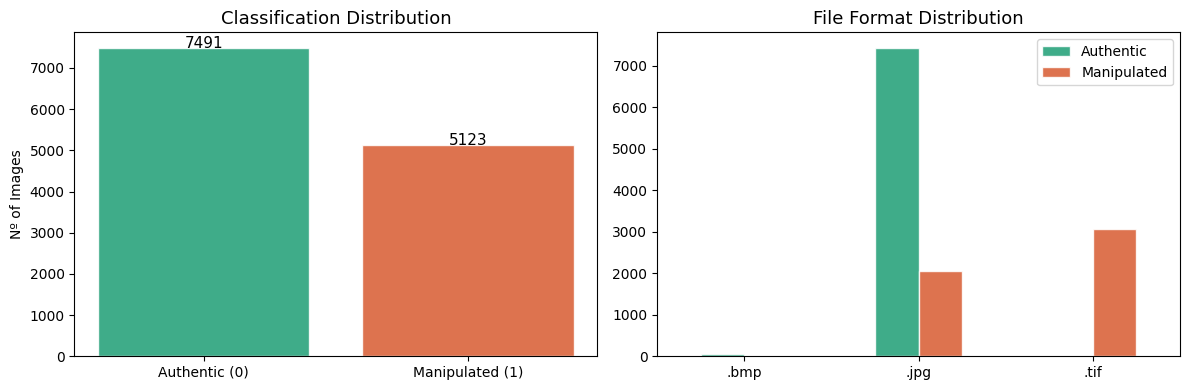


Ratio authentic/manipulated: 1.46x
→ There is an imbalance. We will handle it with class_weight during training.

=== Image Format Distribution ===
Authentic (7491 images):
 .jpg  :  7437 (99.3%)
 .bmp  :    54 (0.7%)

Manipulated (5123 images):
 .tif  :  3059 (59.7%)
 .jpg  :  2064 (40.3%)



In [3]:
fig, axes  = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
counts = df['label'].value_counts().sort_index()
axes[0].bar(['Authentic (0)', 'Manipulated (1)'], counts.values,
            color=['#1D9E75', '#D85A30'], alpha=0.85, edgecolor='white')
axes[0].set_title('Classification Distribution', fontsize=13)
axes[0].set_ylabel('Nº of Images')
for i, v  in enumerate (counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Format distribution
ext_label = df.groupby(['ext','label']).size().unstack(fill_value=0)
ext_label.plot(kind='bar', ax=axes[1], color=['#1D9E75','#D85A30'],
               alpha=0.85, edgecolor='white')
axes[1].set_title('File Format Distribution', fontsize=13)
axes[1].set_xlabel('')
axes[1].legend(['Authentic','Manipulated'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ratio = (df.label==0).sum() / (df.label==1).sum()
print(f"\nRatio authentic/manipulated: {ratio:.2f}x")
print("→ There is an imbalance. We will handle it with class_weight during training.")

print('\n=== Image Format Distribution ===')

for LABEL, NAME in [0, 'Authentic'], [1, 'Manipulated']:
    subset = df[df['label'] == LABEL]
    print(f'{NAME} ({len(subset)} images):')
    for ext, count in subset['ext'].value_counts().items():
        pct = (count / len(subset)) * 100
        print(f' {ext:6s}: {count:5d} ({pct:.1f}%)')
    print()


### 1.2. Image Size Analysis

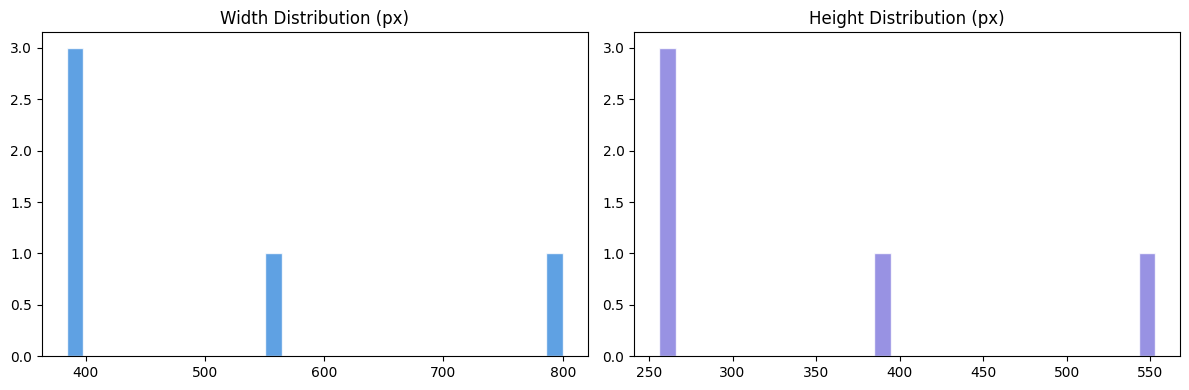

Width  — min: 384px  max: 800px  mean: 503px
Height — min: 256px  max: 553px  mean: 342px

We need to resize all images to a fixed size (224x224 or 300x300) before training.


In [4]:
sample = df.sample(5, random_state=42)
widths, heights = [], []

for path in sample['path']:
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except:
        widths.append(None)
        heights.append(None)

sample = sample.copy()
sample['width'] = widths
sample['height'] = heights
sample = sample.dropna(subset=['width', 'height'])

fig,axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sample['width'],  bins=30, color='#378ADD', alpha=0.8, edgecolor='white')
axes[0].set_title('Width Distribution (px)')
axes[1].hist(sample['height'], bins=30, color='#7F77DD', alpha=0.8, edgecolor='white')
axes[1].set_title('Height Distribution (px)')
plt.tight_layout()
plt.show()

print(f"Width  — min: {sample.width.min():.0f}px  max: {sample.width.max():.0f}px  mean: {sample.width.mean():.0f}px")
print(f"Height — min: {sample.height.min():.0f}px  max: {sample.height.max():.0f}px  mean: {sample.height.mean():.0f}px")
print('\nWe need to resize all images to a fixed size (224x224 or 300x300) before training.')

## 2. JPG Conversion + Resizing

In [10]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_AU = PROCESSED_DIR / "Au"
PROCESSED_TP = PROCESSED_DIR / "Tp"
PROCESSED_AU.mkdir(parents=True, exist_ok=True)
PROCESSED_TP.mkdir(parents=True, exist_ok=True)

def convert_and_save(src_path, dst_folder, img_size=(300,300)):
    '''
    Convert image to JPG, then to RGB and resize to target size.
    RGB is needed as TIF and BMP can have different modes
    '''
    src=Path(src_path)
    dst = dst_folder / (src.stem + '.jpg')

    if dst.exists():
        return dst
    
    with Image.open(src) as img:
        img = img.convert('RGB')
        img = img.resize(img_size, Image.LANCZOS)
        img.save(dst, format='JPEG', quality=95)
    return dst

print('Processing images...')
print('Processing Authentic images...')
au_rows=df[df['label']==0]
for i, (_,row) in enumerate(au_rows.iterrows(), 1):
    convert_and_save(row['path'], PROCESSED_AU)
    if (i+1) % 500 == 0: 
        print(f'Processed {i}/{len(au_rows)} Authentic images')

print('Processing Manipulated images...')
tp_rows=df[df['label']==1]
for i, (_,row) in enumerate(tp_rows.iterrows(), 1):
    convert_and_save(row['path'], PROCESSED_TP)
    if (i+1) % 500 == 0: 
        print(f'Processed {i}/{len(tp_rows)} Manipulated images')

print('\n Conversion and resizing completed')
print(f'Processed Authentic images: {len(list(PROCESSED_AU.glob("*.jpg")))}')
print(f'Processed Manipulated images: {len(list(PROCESSED_TP.glob("*.jpg")))}')

Processing images...
Processing Authentic images...
Processed 499/7491 Authentic images
Processed 999/7491 Authentic images
Processed 1499/7491 Authentic images
Processed 1999/7491 Authentic images
Processed 2499/7491 Authentic images
Processed 2999/7491 Authentic images
Processed 3499/7491 Authentic images
Processed 3999/7491 Authentic images
Processed 4499/7491 Authentic images
Processed 4999/7491 Authentic images
Processed 5499/7491 Authentic images
Processed 5999/7491 Authentic images
Processed 6499/7491 Authentic images
Processed 6999/7491 Authentic images
Processing Manipulated images...
Processed 499/5123 Manipulated images
Processed 999/5123 Manipulated images
Processed 1499/5123 Manipulated images
Processed 1999/5123 Manipulated images
Processed 2499/5123 Manipulated images
Processed 2999/5123 Manipulated images
Processed 3499/5123 Manipulated images
Processed 3999/5123 Manipulated images
Processed 4499/5123 Manipulated images
Processed 4999/5123 Manipulated images

 Conversio

## 3. Splitting Dataset into Train, Val, Test and Saving to CSV

In [11]:
#Dataset Creation
processed_rows = []
for f in  PROCESSED_AU.glob("*.jpg"):
    processed_rows.append({'path': str(f), 'label': 0})
for f in  PROCESSED_TP.glob("*.jpg"):
    processed_rows.append({'path': str(f), 'label': 1})

df_proc = pd.DataFrame(processed_rows)

#We will use stratified samping for data splits
train_df, temp_df = train_test_split(
    df_proc, test_size=0.2, random_state=42, stratify=df_proc['label'])

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

# Display splits info
print('== Dataset Splits ==')
for name, split in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    n_real = (split['label'] == 0).sum()
    n_fake = (split['label'] == 1).sum()
    print(f'{name}: {len(split):5d} images '
          f'(real: {n_real:5d}, manipulated: {n_fake:5d}, '
          f'ratio: {n_real/n_fake:.2f}x)') 
    

# Saving splits
splits_dir = Path("../data/splits")
train_df.to_csv(splits_dir / "train.csv", index=False)
val_df.to_csv(splits_dir  / "val.csv",   index=False)
test_df.to_csv(splits_dir / "test.csv",  index=False)
print('\nCSVs Saved in ../data/splits/')

== Dataset Splits ==
Train: 10091 images (real:  5993, manipulated:  4098, ratio: 1.46x)
Validation:  1261 images (real:   749, manipulated:   512, ratio: 1.46x)
Test:  1262 images (real:   749, manipulated:   513, ratio: 1.46x)

CSVs Saved in ../data/splits/


## 4. Analyzing Grountruth Images (They indicate the manipulated regions in the fake images)

In [ ]:
# First insights on Groundtruth masks
gt_files = list(GT_DIR.iterdir())
exts = {}
for f in gt_files:
    exts[f.suffix.lower()]= exts.get(f.suffix.lower(), 0) + 1
print(f'Total Masks: {len(gt_files)}')
print(f'File Extensions: {exts}')


Total Masks: 5123
File Extensions: {'.png': 5123}


We will visualize 4 random pairs of real and fake images along with their corresponding groundtruth masks to understand the nature of the manipulations.

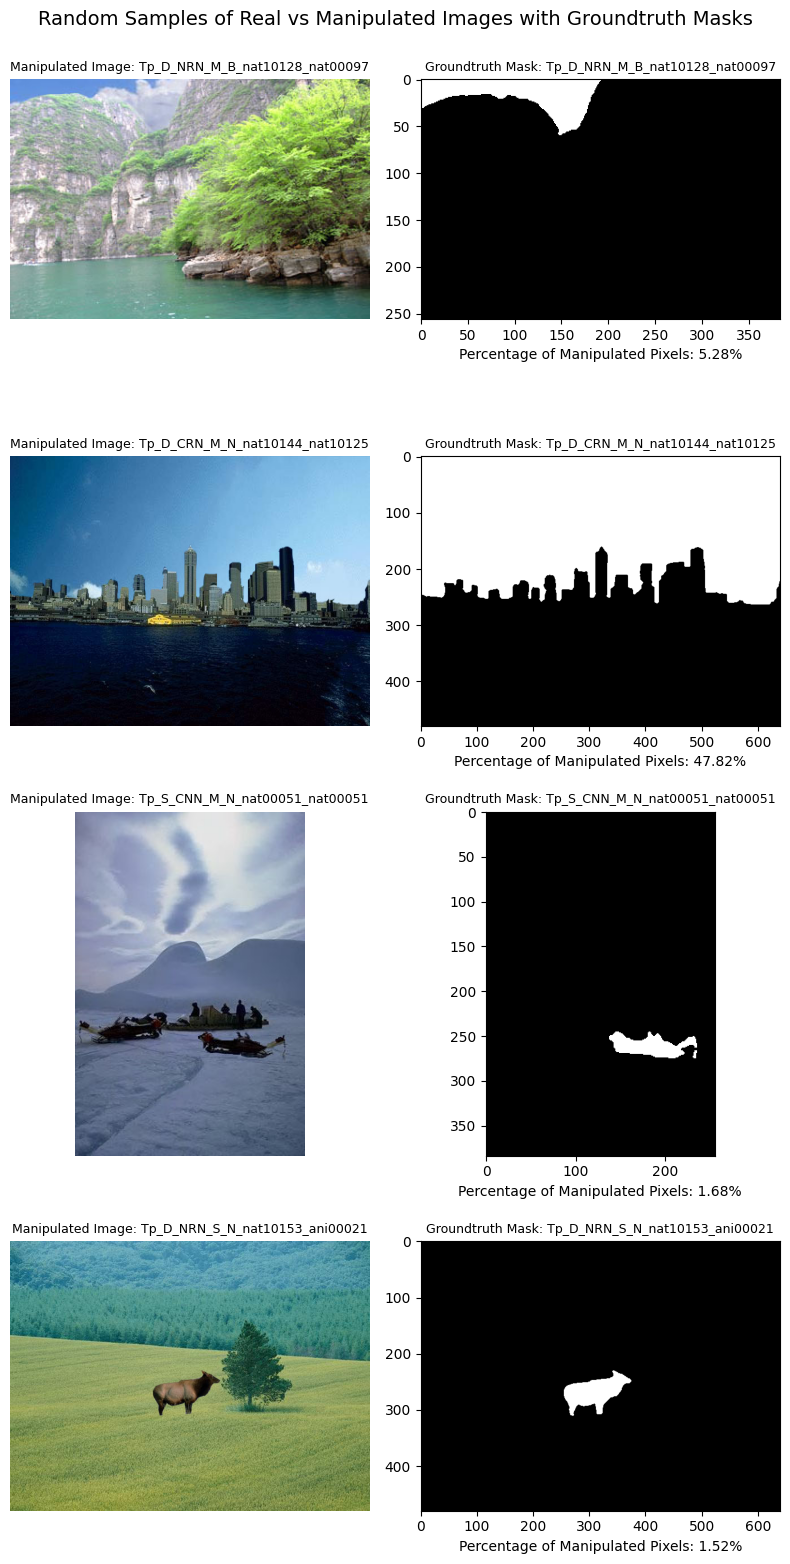

In [ ]:
random.seed(42)  # For reproducibility

fig, axes = plt.subplots(4,2, figsize=(8, 16))
fig.suptitle('Random Samples of Real vs Manipulated Images with Groundtruth Masks', fontsize=14)

tp_samples = random.sample(list(TP_DIR.glob("*.jpg")), 4)
for i, tp_path in enumerate(tp_samples):
    
    stem = tp_path.stem
    mask_candidates = list(GT_DIR.glob(f"*{stem}*"))

    axes[i, 0].imshow(Image.open(tp_path))
    axes[i, 0].set_title(f'Manipulated Image: {tp_path.name[:30]}', fontsize=9)
    axes[i, 0].axis('off')

    if mask_candidates:
        mask= Image.open(mask_candidates[0])
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title(f'Groundtruth Mask: {mask_candidates[0].name[:30]}', fontsize=9)
        # We calculate the percentage of manipulated pixels 
        # (we only consider pixels >128 as manipulated to avoid noise)
        mask_array = np.array(mask)
        pct = (mask_array > 128).sum() / mask_array.size * 100
        axes[i, 1].set_xlabel(f'Percentage of Manipulated Pixels: {pct:.2f}%')

    else:
        axes[i, 1].set_title("Mask not found", fontsize=9)
        axes[i, 1].axis("off")




plt.tight_layout()
plt.show()